In [ ]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: light
#       format_version: '1.5'
#       jupytext_version: 1.14.5
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---

# %% [markdown]
# # Phase 5: Data Visualization for Key Insights
#
# **Objective:** To create clear, compelling, and informative visualizations that effectively communicate the analytical findings from Phase 4.

 ### Notebook Setup: Load Data and Libraries

 We'll begin by importing the necessary visualization libraries (`matplotlib` and `seaborn`) and loading our cleaned dataset.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a visually appealing style for the plots.
sns.set_style("whitegrid")

# Define the filename of the cleaned data.
cleaned_data_filename = "ndcp_2008-2022_cleaned.csv"

try:
    # Load the cleaned CSV data.
    df = pd.read_csv(cleaned_data_filename, dtype={'county_fips_code': str})
    print(f"Successfully loaded '{cleaned_data_filename}'.")
except FileNotFoundError:
    print(f"ERROR: The file '{cleaned_data_filename}' was not found.")
    print("Please run the 'ndcp_data_cleaning.py' script first.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded 'ndcp_2008-2022_cleaned.csv'.


 ### Visualization 1: National Trend of Childcare Costs (Line Chart)

 This line chart will visualize the finding from our first analysis, showing how the national average weekly cost for infant center-based care (`mcinfant`) has changed over the years. This is a powerful way to show the trend of rising costs.

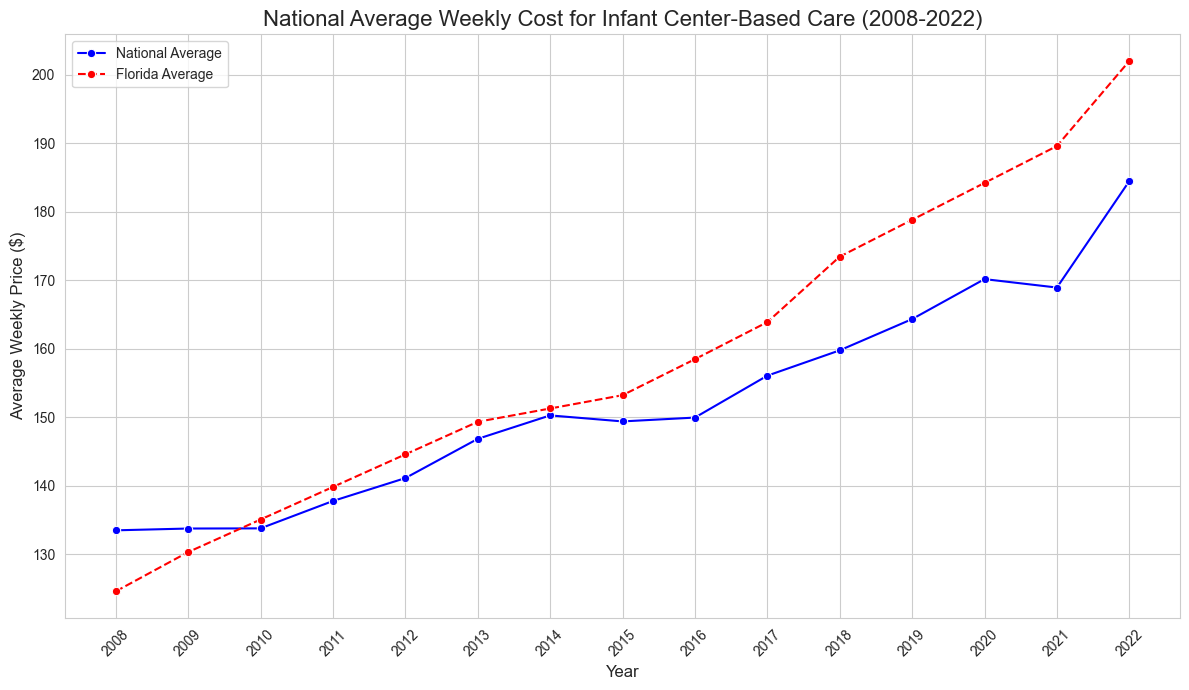

In [ ]:
# Ensure the dataframe is loaded before proceeding
if 'df' in locals():
    # Drop rows where 'mcinfant' is missing to ensure an accurate average.
    price_trends_df = df.dropna(subset=['mcinfant'])

    # --- EDIT: Calculate Florida-specific average price ---
    # This will result in an empty DataFrame if Florida data is missing, but won't cause an error.
    florida_avg_price = price_trends_df[price_trends_df['state_name'] == 'Florida'].groupby('studyyear')['mcinfant'].mean().reset_index()

    # Group by year and calculate the national average price.
    national_avg_price = price_trends_df.groupby('studyyear')['mcinfant'].mean().reset_index()

    # Create the plot.
    plt.figure(figsize=(12, 7))
    # Plot the national average
    sns.lineplot(x='studyyear', y='mcinfant', data=national_avg_price, marker='o', color='b', label='National Average')

    # --- EDIT: Conditionally plot Florida data if it exists ---
    if not florida_avg_price.empty:
        sns.lineplot(x='studyyear', y='mcinfant', data=florida_avg_price, marker='o', linestyle='--', color='red', label='Florida Average')

    # Add titles and labels for clarity.
    plt.title('National Average Weekly Cost for Infant Center-Based Care (2008-2022)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Average Weekly Price ($)', fontsize=12)
    plt.xticks(national_avg_price['studyyear'], rotation=45)
    plt.legend() # Add a legend to distinguish the lines
    plt.tight_layout() # Adjust plot to prevent labels from overlapping

    # Display the plot.
    plt.show()

 ### Visualization 2: Geographic Disparity in Childcare Costs (Bar Chart)

 To highlight the significant difference in costs across the country, we'll create a horizontal bar chart. This chart will rank all available states by their average infant care cost, making it easy to see the most and least expensive states.

<ipython-input-4-0cc08f200515>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mcinfant', y='state_name', data=avg_price_by_state, palette=palette_colors)


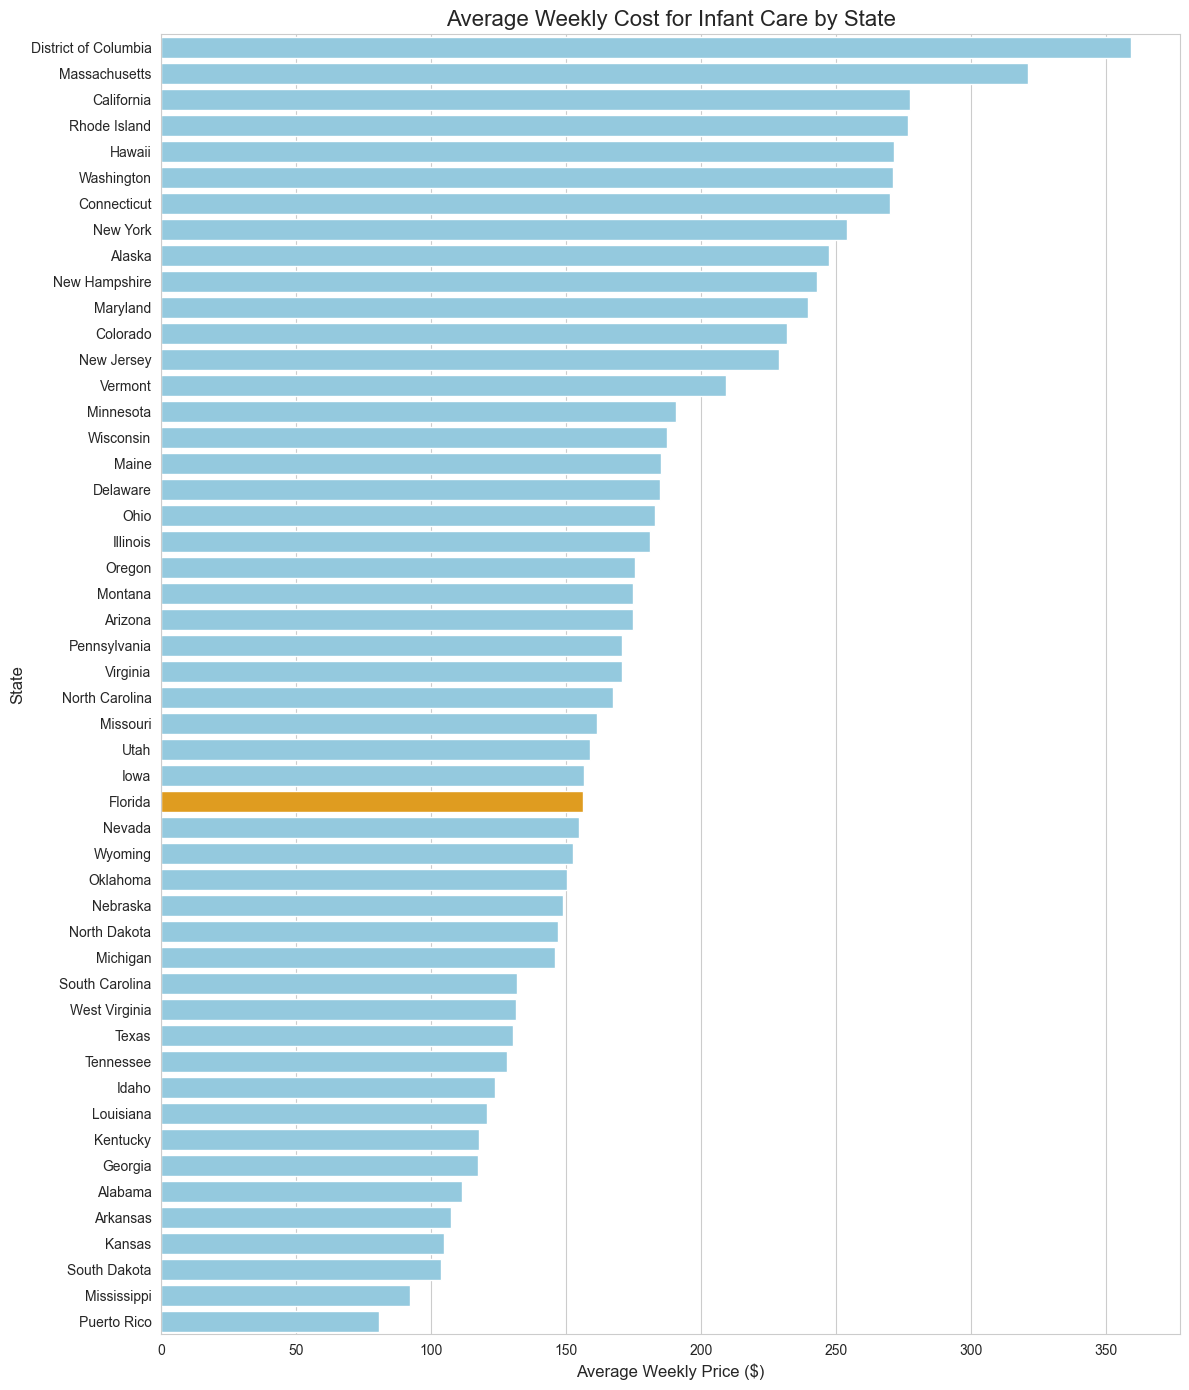

In [ ]:
# Ensure the dataframe is loaded before proceeding
if 'df' in locals():
    # Group by state and calculate the average price, then sort.
    avg_price_by_state = df.dropna(subset=['mcinfant']).groupby('state_name')['mcinfant'].mean().sort_values(ascending=False).reset_index()

    # --- EDIT: Create a dynamic color palette to highlight Florida ---
    # If Florida is in the data, its bar will be orange; otherwise, all bars will be blue.
    palette_colors = ['orange' if state == 'Florida' else 'skyblue' for state in avg_price_by_state['state_name']]

    # Create the plot.
    plt.figure(figsize=(12, 14))
    sns.barplot(x='mcinfant', y='state_name', data=avg_price_by_state, palette=palette_colors)

    # Add titles and labels.
    plt.title('Average Weekly Cost for Infant Care by State', fontsize=16)
    plt.xlabel('Average Weekly Price ($)', fontsize=12)
    plt.ylabel('State', fontsize=12)
    plt.tight_layout()

    # Display the plot.
    plt.show()

 ### Visualization 3: Correlation Between Income and Childcare Costs (Scatter Plot)

 This visualization will explore the relationship between a county's median household income and the price of infant care. A scatter plot with a regression line (`regplot`) is perfect for this, as it shows both the individual data points and the overall trend.

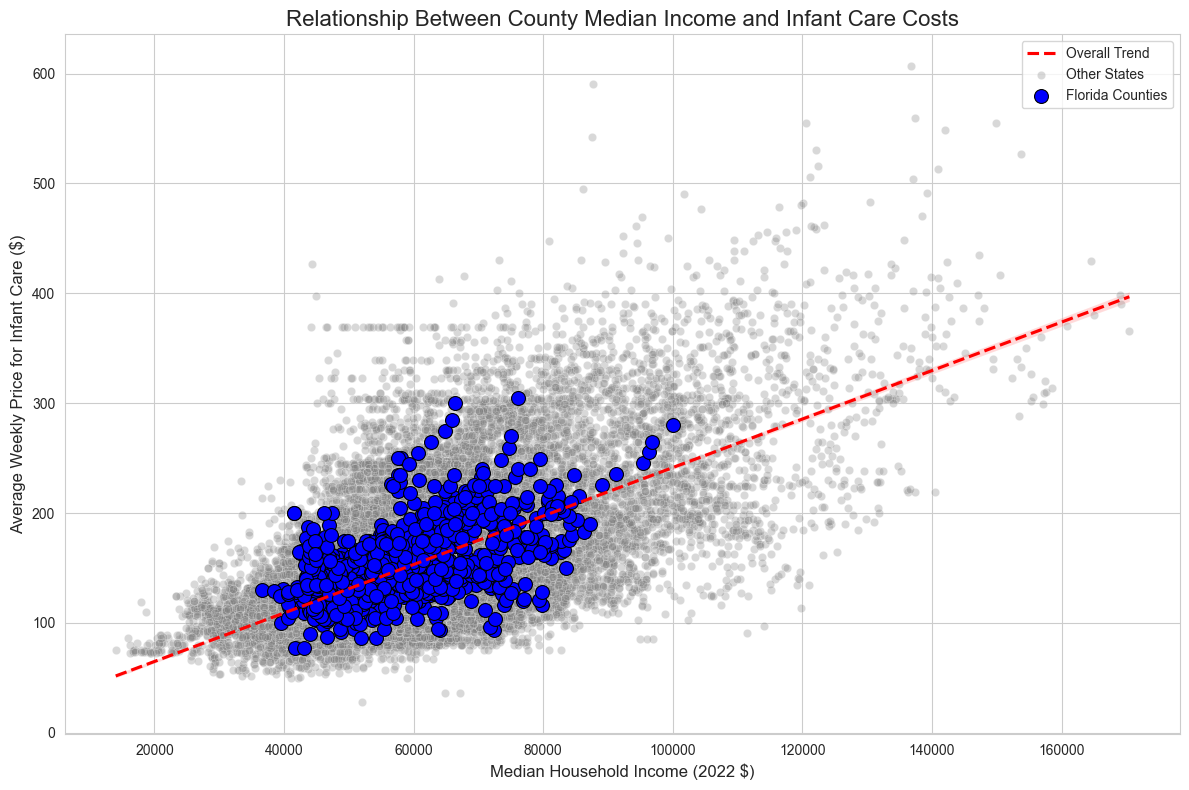

In [ ]:
# Ensure the dataframe is loaded before proceeding
if 'df' in locals():
    # Create a focused DataFrame, dropping missing values for a clean plot.
    # Using the corrected 'mhi_2022' column.
    correlation_df = df[['mcinfant', 'mhi_2022', 'state_name']].dropna()

    # --- EDIT: Separate Florida data to plot it with emphasis ---
    florida_data = correlation_df[correlation_df['state_name'] == 'Florida']
    other_states_data = correlation_df[correlation_df['state_name'] != 'Florida']

    # Create the scatter plot with a regression line.
    plt.figure(figsize=(12, 8))

    # Plot the regression line for all data first.
    sns.regplot(x='mhi_2022', y='mcinfant', data=correlation_df,
                scatter=False, # Don't plot the points with this call
                line_kws={'color':'red', 'linestyle':'--'}, label='Overall Trend')

    # Plot the points for all other states.
    sns.scatterplot(x='mhi_2022', y='mcinfant', data=other_states_data,
                    color='gray', alpha=0.3, label='Other States')

    # If Florida data exists, plot its points on top.
    if not florida_data.empty:
        sns.scatterplot(x='mhi_2022', y='mcinfant', data=florida_data,
                        color='blue', s=100, ec='black', label='Florida Counties')

    # Add titles and labels.
    plt.title('Relationship Between County Median Income and Infant Care Costs', fontsize=16)
    plt.xlabel('Median Household Income (2022 $)', fontsize=12)
    plt.ylabel('Average Weekly Price for Infant Care ($)', fontsize=12)
    plt.legend()
    plt.tight_layout()

    # Display the plot.
    plt.show()